In [9]:
import time
from io import StringIO
from typing import List, Optional, Union, Dict

import numpy as np
import pandas as pd
import requests


# =========================================================
# 0) 지역(국가/집계) 코드 매핑
#    - OECD DF_CLI는 REF_AREA에 ISO3 국가코드와 G20 같은 집계코드를 씁니다. :contentReference[oaicite:2]{index=2}
# =========================================================
OECD_AREA_MAP: Dict[str, str] = {
    # aggregates
    "G20": "G20",

    # countries (ISO3)
    "한국": "KOR", "KOR": "KOR",
    "미국": "USA", "USA": "USA",
    "일본": "JPN", "JPN": "JPN",

    "멕시코": "MEX", "MEX": "MEX",
    "영국": "GBR", "GBR": "GBR", "UK": "GBR",
    "프랑스": "FRA", "FRA": "FRA",
    "스페인": "ESP", "ESP": "ESP",
    "독일": "DEU", "DEU": "DEU", "GER": "DEU",
    "이탈리아": "ITA", "ITA": "ITA",
    "오스트레일리아": "AUS", "AUS": "AUS",
    "캐나다": "CAN", "CAN": "CAN",
}


def resolve_oecd_areas(items: List[str]) -> List[str]:
    out = []
    for x in items:
        x = str(x).strip()
        code = OECD_AREA_MAP.get(x, x)  # 매핑 없으면 입력 그대로(이미 ISO3일 수 있음)
        out.append(code)
    # 중복 제거(순서 유지)
    seen = set()
    uniq = []
    for c in out:
        if c not in seen:
            uniq.append(c)
            seen.add(c)
    return uniq


# =========================================================
# 1) OECD CLI API 수집
#   - OECD 공식 API 문서 예시: /public/rest/data/OECD.SDD.STES,DSD_STES@DF_CLI/... :contentReference[oaicite:3]{index=3}
#   - G20 조회 예시는 dq=G20.M.LI...AA...H 형태로 공개되어 있음 :contentReference[oaicite:4]{index=4}
# =========================================================
def fetch_oecd_cli(
    areas: List[str],
    start_period: str = "1990-01",
    end_period: Optional[str] = None,
    timeout: int = 60,
    sleep_sec: float = 0.15,
    use_labels: bool = True,
) -> pd.DataFrame:
    """
    areas: REF_AREA 코드 리스트 (예: ["G20","KOR","USA","JPN","GBR","DEU"...])
    key: {REF_AREA}.M.LI...AA...H  (월별 CLI, amplitude-adjusted, harmonised)
    """
    base = "https://sdmx.oecd.org/public/rest/data/OECD.SDD.STES,DSD_STES@DF_CLI,4.1"

    # 여러 국가를 + 로 묶어서 한 번에 호출 가능
    area_part = "+".join(areas)
    key = f"{area_part}.M.LI...AA...H"

    params = {
        "startPeriod": start_period,
        "dimensionAtObservation": "AllDimensions",
        "format": "csvfilewithlabels" if use_labels else "csvfile",
    }
    if end_period:
        params["endPeriod"] = end_period

    url = f"{base}/{key}"

    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; OECD-CLI-fetcher/1.0)",
        "Accept": "text/csv",
    }

    r = requests.get(url, params=params, headers=headers, timeout=timeout)
    if r.status_code != 200:
        raise RuntimeError(f"OECD API failed: {r.status_code} / {r.text[:300]}")

    df = pd.read_csv(StringIO(r.text))
    time.sleep(sleep_sec)
    return df


# =========================================================
# 2) 국면 분류 (확장/둔화/저점/회복)
#   - 기준: 레벨(100) vs 모멘텀(+)의 4분면
# =========================================================
def classify_cli_phases(
    df_cli: pd.DataFrame,
    threshold: float = 100.0,
    mom_window: int = 3,
) -> pd.DataFrame:
    """
    확장: cli>=100 & mom>0
    둔화: cli>=100 & mom<0
    저점: cli<100 & mom<0
    회복: cli<100 & mom>0
    """

    df = df_cli.copy()

    # 컬럼 자동 탐색 (csvfilewithlabels / csvfile 차이 대응)
    candidates = {
        "area": ["REF_AREA", "Reference area", "LOCATION", "REF_AREA (code)"],
        "time": ["TIME_PERIOD", "Time period"],
        "cli":  ["OBS_VALUE", "Observation Value", "OBS_VALUE (value)"],
    }

    def pick(colkey):
        for c in candidates[colkey]:
            if c in df.columns:
                return c
        raise KeyError(f"필수 컬럼({colkey})을 찾지 못했습니다. cols={list(df.columns)[:50]}")

    acol, tcol, vcol = pick("area"), pick("time"), pick("cli")

    df = df.rename(columns={acol: "area", tcol: "time", vcol: "cli"})
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df["cli"] = pd.to_numeric(df["cli"], errors="coerce")
    df = df.dropna(subset=["area", "time", "cli"]).sort_values(["area", "time"]).reset_index(drop=True)

    df["mom"] = df.groupby("area")["cli"].diff(mom_window)

    above = df["cli"] >= threshold
    up = df["mom"] > 0
    down = df["mom"] < 0

    df["phase"] = np.select(
        [
            df["mom"].isna(),
            above & up,
            above & down,
            (~above) & down,
            (~above) & up,
            df["mom"] == 0,
        ],
        [
            np.nan,
            "확장",
            "둔화",
            "저점",
            "회복",
            "중립",
        ],
        default="중립",
    )

    df["phase_change"] = df.groupby("area")["phase"].transform(lambda s: s.ne(s.shift(1)))

    return df


# =========================================================
# 3) 한 번에 실행 (요청 국가 + G20 포함)
# =========================================================
def get_cli_with_phases(
    targets: Optional[List[str]] = None,
    start_period: str = "2008-01",
    end_period: Optional[str] = None,
    mom_window: int = 3,
) -> pd.DataFrame:
    """
    targets에 한글/영문/ISO3 섞어서 넣어도 됨.
    예: ["G20","멕시코","영국","프랑스","스페인","독일","이탈리아","오스트레일리아","캐나다"]
    """
    if targets is None:
        targets = [
            "G20",
            "멕시코", "영국", "프랑스", "스페인", "독일", "이탈리아", "오스트레일리아", "캐나다",
            "한국", "미국", "일본",
        ]

    areas = resolve_oecd_areas(targets)

    raw = fetch_oecd_cli(
        areas=areas,
        start_period=start_period,
        end_period=end_period,
        use_labels=True
    )
    out = classify_cli_phases(raw, mom_window=mom_window)
    return out


# ===========================
# 사용 예시
# ===========================
# if __name__ == "__main__":
#     df = get_cli_with_phases(
#         targets=["G20","멕시코","영국","프랑스","스페인","독일","이탈리아","오스트레일리아","캐나다"],
#         start_period="2008-01",
#         mom_window=3
#     )
#     print(df[df["area"].isin(["G20","MEX","GBR","FRA","ESP","DEU","ITA","AUS","CAN"])].tail(20))


In [12]:
df = get_cli_with_phases(
    targets=["G20","멕시코","영국","프랑스","스페인","독일","이탈리아","오스트레일리아","캐나다"],
    start_period="2008-01",
    mom_window=3)

# print(df[df["area"].isin(["G20","MEX","GBR","FRA","ESP","DEU","ITA","AUS","CAN"])].tail(20))
print(df[df["area"].isin(["G20"])].tail(20))

     STRUCTURE                        STRUCTURE_ID  \
1282  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1283  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1284  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1285  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1286  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1287  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1288  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1289  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1290  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1291  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1292  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1293  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1294  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1295  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1296  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1297  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1298  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
1299  DATAFLOW  OECD.SDD.STE

In [14]:
G20 = df[df["area"].isin(["G20"])]

<AxesSubplot: >

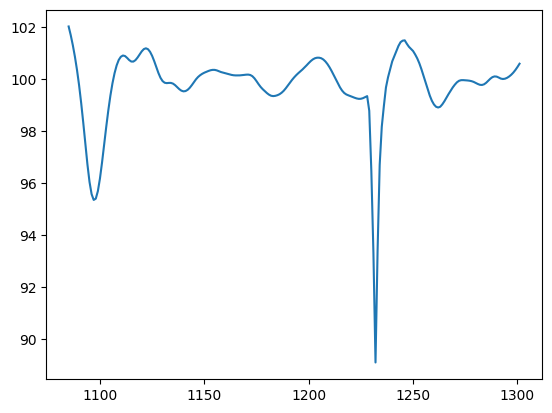

In [16]:
G20['cli'].plot()

In [9]:
import time
from io import StringIO
from typing import List, Optional, Dict, Set

import numpy as np
import pandas as pd
import requests

DATA_ENDPOINT = "https://sdmx.oecd.org/public/rest/data"


# =========================================================
# 1) OECD CSV fetch (버전 생략 → 최신 자동)
#   - OECD FAQ 예시도 버전 없이 호출함 :contentReference[oaicite:1]{index=1}
# =========================================================
def fetch_oecd_csv(
    resource_id: str,   # 예: "OECD.SDD.STES,DSD_STES@DF_CLI"  (버전 생략)
    key: str,
    start_period: str,
    end_period: Optional[str] = None,
    timeout: int = 60,
    labels: bool = True,
    sleep_sec: float = 0.15,
) -> pd.DataFrame:
    params = {
        "startPeriod": start_period,
        "dimensionAtObservation": "AllDimensions",
        "format": "csvfilewithlabels" if labels else "csvfile",
    }
    if end_period:
        params["endPeriod"] = end_period

    url = f"{DATA_ENDPOINT}/{resource_id}/{key}"

    r = requests.get(url, params=params, timeout=timeout, headers={"Accept": "text/csv"})
    if r.status_code != 200:
        raise RuntimeError(f"OECD API failed: {r.status_code} / {r.text[:400]}")

    time.sleep(sleep_sec)
    return pd.read_csv(StringIO(r.text))


# =========================================================
# 2) CLI 수집 + 국면분류
#   key 패턴: {AREA}.M.LI...AA...H (OECD 예시 패턴) :contentReference[oaicite:2]{index=2}
# =========================================================
def fetch_cli_and_phase(
    areas: List[str],
    start_period: str = "2000-01",
    end_period: Optional[str] = None,
    mom_window: int = 3,
    threshold: float = 100.0,
) -> pd.DataFrame:
    resource_id = "OECD.SDD.STES,DSD_STES@DF_CLI"

    area_part = "+".join(areas)
    key = f"{area_part}.M.LI...AA...H"

    raw = fetch_oecd_csv(resource_id, key, start_period, end_period, labels=True)

    def pick(df, cands):
        for c in cands:
            if c in df.columns:
                return c
        raise KeyError(f"Cannot find columns among: {cands} / got={list(df.columns)[:60]}")

    area_col = pick(raw, ["REF_AREA", "Reference area", "REF_AREA (code)", "LOCATION"])
    time_col = pick(raw, ["TIME_PERIOD", "Time period"])
    val_col  = pick(raw, ["OBS_VALUE", "Observation Value", "OBS_VALUE (value)"])

    df = raw.rename(columns={area_col: "area", time_col: "date", val_col: "cli"}).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["cli"] = pd.to_numeric(df["cli"], errors="coerce")
    df = df.dropna(subset=["area", "date", "cli"]).sort_values(["area", "date"]).reset_index(drop=True)

    df["mom"] = df.groupby("area")["cli"].diff(mom_window)

    above = df["cli"] >= threshold
    up = df["mom"] > 0
    down = df["mom"] < 0

    df["phase"] = np.select(
        [
            df["mom"].isna(),
            above & up,
            above & down,
            (~above) & down,
            (~above) & up,
            df["mom"] == 0,
        ],
        [np.nan, "확장", "둔화", "저점", "회복", "중립"],
        default="중립",
    )

    # ✅ apply 대신 transform 사용(이전 에러 방지)
    df["phase_change"] = df.groupby("area")["phase"].transform(lambda s: s.ne(s.shift(1)))

    return df


# =========================================================
# 3) 금리 수집 (DF_FINMARK) - 단기/장기
#   - DF_FINMARK UI/예시에서 IRLT/IR3TIB 패턴 사용됨 :contentReference[oaicite:3]{index=3}
# =========================================================
def fetch_finmark_rates(
    areas: List[str],
    start_period: str = "2000-01",
    end_period: Optional[str] = None,
    freq: str = "M",          # "M"(월) or "A"(연)
    rate_code: str = "IR3TIB",# 단기: IR3TIB, 장기: IRLT
    measure: str = "PA",      # percent per annum
) -> pd.DataFrame:
    resource_id = "OECD.SDD.STES,DSD_STES@DF_FINMARK"

    area_part = "+".join(areas)
    key = f"{area_part}.{freq}.{rate_code}.{measure}....."

    raw = fetch_oecd_csv(resource_id, key, start_period, end_period, labels=True)

    def pick(df, cands):
        for c in cands:
            if c in df.columns:
                return c
        raise KeyError(f"Cannot find columns among: {cands} / got={list(df.columns)[:60]}")

    area_col = pick(raw, ["REF_AREA", "Reference area", "REF_AREA (code)", "LOCATION"])
    time_col = pick(raw, ["TIME_PERIOD", "Time period"])
    val_col  = pick(raw, ["OBS_VALUE", "Observation Value", "OBS_VALUE (value)"])

    df = raw.rename(columns={area_col: "area", time_col: "date", val_col: "value"}).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["area", "date"]).sort_values(["area", "date"]).reset_index(drop=True)

    df["indicator"] = f"{rate_code}_{measure}_{freq}"
    return df[["date", "area", "indicator", "value"]]


# =========================================================
# 4) 한 번에: CLI+국면 + 금리(단기/장기)
# =========================================================
def collect_oecd_core_macro(
    areas: List[str],
    start_period: str = "2008-01",
    end_period: Optional[str] = None,
    mom_window: int = 3,
) -> Dict[str, pd.DataFrame]:

    cli_phase = fetch_cli_and_phase(
        areas=areas, start_period=start_period, end_period=end_period,
        mom_window=mom_window
    )

    # ✅ (추가) 확산지수 계산: G20은 보통 “표본 국가”가 아니라 집계이므로 제외 권장
    cli_diffusion = compute_cli_diffusion_index(
        cli_df=cli_phase,
        areas=areas,
        exclude_areas={"G20"},
        total_mode="fixed",   # 정의 그대로 “전체국가”를 고정 분모로 사용
    )

    r_short = fetch_finmark_rates(
        areas=areas, start_period=start_period, end_period=end_period,
        freq="M", rate_code="IR3TIB", measure="PA"
    )

    start_year = start_period[:4]
    end_year = end_period[:4] if end_period else None
    r_long = fetch_finmark_rates(
        areas=areas, start_period=start_year, end_period=end_year,
        freq="A", rate_code="IRLT", measure="PA"
    )

    rates_long = pd.concat([r_short, r_long], ignore_index=True)

    return {
        "cli_phase": cli_phase,
        "cli_diffusion": cli_diffusion,  # ✅ (추가)
        "rates_long": rates_long
    }


def compute_cli_diffusion_index(
    cli_df: pd.DataFrame,
    areas: List[str],
    exclude_areas: Optional[Set[str]] = None,
    total_mode: str = "fixed",   # "fixed" (권장) or "available"
) -> pd.DataFrame:
    """
    경기확산지수 정의:
      - 국가별 CLI 전월차(ΔCLI)를 구한다.
      - 특정 월 t에서 ΔCLI>0 인 국가 수 A, ΔCLI<0 인 국가 수 B
      - (A - B) / 전체국가 * 100

    Parameters
    ----------
    cli_df : DataFrame
        fetch_cli_and_phase()의 결과(최소: area, date, cli)
    areas : List[str]
        표본 국가 리스트(분모 계산에 사용)
    exclude_areas : set
        분모/집계에서 제외할 area 코드(예: {"G20"}). 기본은 None.
    total_mode : str
        "fixed"     : 전체국가 = (areas 중 exclude 제외한 개수) (월별 결측 있어도 분모 고정)
        "available" : 전체국가 = 해당 월에 ΔCLI가 존재하는 국가 수(결측 제외)

    Returns
    -------
    DataFrame columns:
        - date
        - A_pos
        - B_neg
        - total
        - diffusion_index
    """
    if exclude_areas is None:
        exclude_areas = set()

    df = cli_df.copy()
    if not {"area", "date", "cli"}.issubset(df.columns):
        raise ValueError("cli_df는 최소 columns=['area','date','cli']를 포함해야 합니다.")

    # 제외 대상 제거(예: G20)
    df = df[~df["area"].isin(exclude_areas)].copy()

    # 전월차(1개월 diff)
    df = df.sort_values(["area", "date"]).reset_index(drop=True)
    df["d_cli_mom"] = df.groupby("area")["cli"].diff(1)

    # A, B 집계
    agg = df.groupby("date")["d_cli_mom"].agg(
        A_pos=lambda s: int((s > 0).sum()),
        B_neg=lambda s: int((s < 0).sum()),
        available=lambda s: int(s.notna().sum()),
    ).reset_index()

    if total_mode not in {"fixed", "available"}:
        raise ValueError("total_mode는 'fixed' 또는 'available'이어야 합니다.")

    if total_mode == "fixed":
        total = len([a for a in areas if a not in exclude_areas])
        agg["total"] = total
    else:
        agg["total"] = agg["available"]

    # 분모 0 방지
    agg["diffusion_index"] = np.where(
        agg["total"] > 0,
        (agg["A_pos"] - agg["B_neg"]) / agg["total"] * 100.0,
        np.nan
    )

    # 결과 정렬
    agg = agg.sort_values("date").reset_index(drop=True)
    return agg[["date", "A_pos", "B_neg", "total", "diffusion_index"]]


# ===========================
# 사용 예시
# ===========================
# if __name__ == "__main__":
#     areas = ["G20","KOR","USA","JPN","GBR","FRA","ESP","DEU","ITA","AUS","CAN","MEX"]
#     out = collect_oecd_core_macro(areas, start_period="2008-01", mom_window=3)
#     print(out["cli_phase"].tail(10))
#     print(out["rates_long"].tail(10))


In [10]:
areas = [
    "G20",
    "KOR", "USA", "JPN",
    "GBR", "FRA", "ESP", "DEU", "ITA",
    "AUS", "CAN", "MEX",
    "CHN",   # 중국
    "IND",   # 인도
    "ZAF",   # 남아프리카공화국
    "IDN",   # 인도네시아
    "TUR",   # 튀르키예
]

out = collect_oecd_core_macro(
    areas,
    start_period="2008-01",
    mom_window=12
)

print(out["cli_phase"].tail(10))
print(out["rates_long"].tail(10))

     STRUCTURE                        STRUCTURE_ID  \
3679  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
3680  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
3681  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
3682  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
3683  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
3684  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
3685  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
3686  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
3687  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   
3688  DATAFLOW  OECD.SDD.STES:DSD_STES@DF_CLI(4.1)   

                    STRUCTURE_NAME ACTION area Reference area FREQ  \
3679  Composite leading indicators      I  ZAF   South Africa    M   
3680  Composite leading indicators      I  ZAF   South Africa    M   
3681  Composite leading indicators      I  ZAF   South Africa    M   
3682  Composite leading indicators      I  ZAF   South Africa    M   
3683  Composite leading indicators      I  ZAF   South 

<AxesSubplot: >

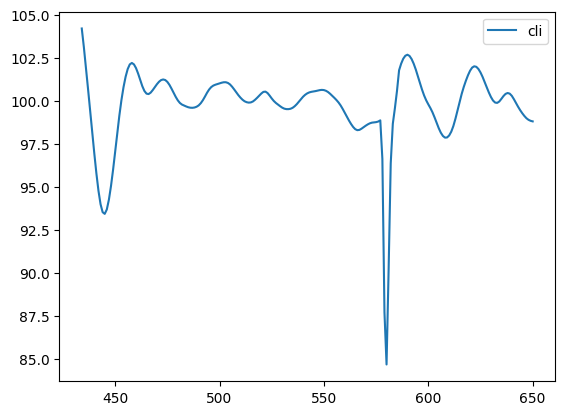

In [11]:
df = out['cli_phase']

df[df['area'] == 'CHN'][['cli']].plot()

In [26]:
out['cli_diffusion']

,date,A_pos,B_neg,total,diffusion_index
0,2008-01-01,0,0,16,0.0
1,2008-02-01,1,15,16,-87.5
2,2008-03-01,1,15,16,-87.5
3,2008-04-01,1,15,16,-87.5
4,2008-05-01,0,16,16,-100.0
...,...,...,...,...,...
212,2025-09-01,15,1,16,87.5
213,2025-10-01,14,2,16,75.0
214,2025-11-01,14,2,16,75.0
215,2025-12-01,15,1,16,87.5


In [22]:

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 오늘 날짜
today_date = datetime.now().strftime('%Y%m%d')

# 저장 경로
save_path = r'C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\Macro\OECD_CLI'
os.makedirs(save_path, exist_ok=True)


# 1. 국가별 CLI 시계열 지표 시각화
def plot_cli_by_country(df, save_path, today_date):
    """
    국가별 CLI(Composite Leading Indicator) 시계열 그래프
    """
    fig, ax = plt.subplots(figsize=(16, 10))

    # area 컬럼의 고유 국가 추출
    countries = df['area'].unique()

    for country in countries:
        country_data = df[df['area'] == country]

        ax.plot(country_data.index,
               country_data['cli'].values,
               label=country,
               linewidth=2,
               marker='o',
               markersize=3,
               alpha=0.7)

    ax.set_xlabel('Date', fontsize=14, fontweight='bold')
    ax.set_ylabel('CLI Value', fontsize=14, fontweight='bold')
    ax.set_title('국가별 경기선행지수(CLI) 시계열 추이', fontsize=16, fontweight='bold', pad=20)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.savefig(f'{save_path}/CLI_by_country_{today_date}.jpg',
                dpi=300,
                bbox_inches='tight')
    plt.close()

    print(f"국가별 CLI 시각화 완료: {save_path}/CLI_by_country_{today_date}.jpg")


# 2. Diffusion Index 시계열 지표 시각화
def plot_diffusion_index(df, save_path, today_date):
    """
    Diffusion Index 시계열 그래프
    """
    # diffusion_index 컬럼이 있는지 확인
    if 'diffusion_index' not in df.columns:
        print("diffusion_index 컬럼을 찾을 수 없습니다.")
        return

    fig, ax = plt.subplots(figsize=(16, 10))

    # area 컬럼의 고유 국가 추출
    countries = df['area'].unique()

    for country in countries:
        country_data = df[df['area'] == country]

        ax.plot(country_data.index,
               country_data['diffusion_index'].values,
               label=country,
               linewidth=2,
               marker='s',
               markersize=3,
               alpha=0.7)

    # 기준선 (100) 추가
    ax.axhline(y=100, color='red', linestyle='--', linewidth=2, alpha=0.5, label='기준선 (100)')

    ax.set_xlabel('Date', fontsize=14, fontweight='bold')
    ax.set_ylabel('Diffusion Index', fontsize=14, fontweight='bold')
    ax.set_title('국가별 확산지수(Diffusion Index) 시계열 추이', fontsize=16, fontweight='bold', pad=20)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.savefig(f'{save_path}/Diffusion_Index_{today_date}.jpg',
                dpi=300,
                bbox_inches='tight')
    plt.close()

    print(f"Diffusion Index 시각화 완료: {save_path}/Diffusion_Index_{today_date}.jpg")


# 3. 주요 국가별 개별 차트 (CLI + Diffusion Index)
def plot_country_individual(df, save_path, today_date):
    """
    주요 국가별로 CLI와 Diffusion Index를 함께 표시
    """
    countries = df['area'].unique()

    # 서브플롯 개수 계산
    n_countries = len(countries)
    n_cols = 3
    n_rows = (n_countries + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = axes.flatten() if n_countries > 1 else [axes]

    has_di = 'diffusion_index' in df.columns

    for idx, country in enumerate(countries):
        ax1 = axes[idx]
        country_data = df[df['area'] == country]

        # CLI 데이터 플롯
        ax1.plot(country_data.index,
                country_data['cli'].values,
                color='blue',
                linewidth=2,
                label='CLI',
                marker='o',
                markersize=4)
        ax1.set_ylabel('CLI', fontsize=11, fontweight='bold', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')

        # Diffusion Index 플롯 (두 번째 y축)
        if has_di:
            ax2 = ax1.twinx()
            ax2.plot(country_data.index,
                    country_data['diffusion_index'].values,
                    color='red',
                    linewidth=2,
                    label='Diffusion Index',
                    marker='s',
                    markersize=4)
            ax2.axhline(y=100, color='red', linestyle='--', linewidth=1, alpha=0.3)
            ax2.set_ylabel('Diffusion Index', fontsize=11, fontweight='bold', color='red')
            ax2.tick_params(axis='y', labelcolor='red')

        ax1.set_title(f'{country}', fontsize=13, fontweight='bold', pad=10)
        ax1.grid(True, alpha=0.3, linestyle='--')
        ax1.tick_params(axis='x', rotation=45)

        # 범례
        lines1, labels1 = ax1.get_legend_handles_labels()
        if has_di:
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
        else:
            ax1.legend(loc='upper left', fontsize=9)

    # 남은 서브플롯 숨기기
    for idx in range(n_countries, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(f'{save_path}/Country_Individual_Analysis_{today_date}.jpg',
                dpi=300,
                bbox_inches='tight')
    plt.close()

    print(f"국가별 개별 분석 시각화 완료: {save_path}/Country_Individual_Analysis_{today_date}.jpg")


# 4. 최근 추세 분석 (전월 대비 변화율)
def plot_mom_changes(df, save_path, today_date):
    """
    CLI 전월 대비 변화율 히트맵
    """
    # MoM 컬럼이 있는지 확인
    mom_col = None
    for col in df.columns:
        if 'mom' in col.lower() or 'diff' in col.lower():
            mom_col = col
            break

    if mom_col is None:
        print("MoM 변화율 컬럼을 찾을 수 없습니다.")
        return

    # 피벗 테이블 생성 (국가별 x 시간)
    pivot_data = df.pivot(columns='area', values=mom_col)

    # 최근 24개월 데이터
    recent_data = pivot_data.tail(24)

    if len(recent_data) == 0:
        print("최근 데이터가 없습니다.")
        return

    fig, ax = plt.subplots(figsize=(16, 10))

    sns.heatmap(recent_data.T,
                annot=True,
                fmt='.2f',
                cmap='RdYlGn',
                center=0,
                cbar_kws={'label': '전월 대비 변화율 (%)'},
                linewidths=0.5,
                ax=ax)

    ax.set_title('국가별 CLI 전월 대비 변화율 추이 (최근 24개월)',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Date', fontsize=14, fontweight='bold')
    ax.set_ylabel('Country', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{save_path}/CLI_MoM_Heatmap_{today_date}.jpg',
                dpi=300,
                bbox_inches='tight')
    plt.close()

    print(f"MoM 변화율 히트맵 시각화 완료: {save_path}/CLI_MoM_Heatmap_{today_date}.jpg")


# 메인 실행 함수
def visualize_oecd_data(out):
    """
    OECD 데이터 시각화 메인 함수

    Parameters:
    -----------
    out : dict
        collect_oecd_core_macro() 함수로부터 생성된 dictionary
    """
    print("=" * 80)
    print("OECD CLI 데이터 시각화 시작")
    print("=" * 80)

    # cli_phase 데이터 추출
    df = out['cli_phase']

    print(f"\n데이터 shape: {df.shape}")
    print(f"데이터 기간: {df.index[0]} ~ {df.index[-1]}")
    print(f"컬럼: {list(df.columns)}")
    print(f"국가 목록: {df['area'].unique().tolist()}")

    print("\n시각화 작업을 시작합니다...\n")

    # 1. 국가별 CLI 시계열
    plot_cli_by_country(df, save_path, today_date)

    # 2. Diffusion Index 시계열
    plot_diffusion_index(df, save_path, today_date)

    # 3. 국가별 개별 차트
    plot_country_individual(df, save_path, today_date)

    # 4. MoM 변화율 히트맵
    plot_mom_changes(df, save_path, today_date)

    print("\n" + "=" * 80)
    print("모든 시각화 작업이 완료되었습니다!")
    print(f"저장 경로: {save_path}")
    print("=" * 80)


# 실행
visualize_oecd_data(out)

OECD CLI 데이터 시각화 시작

데이터 shape: (3689, 37)
데이터 기간: 0 ~ 3688
컬럼: ['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'area', 'Reference area', 'FREQ', 'Frequency of observation', 'MEASURE', 'Measure', 'UNIT_MEASURE', 'Unit of measure', 'ACTIVITY', 'Economic activity', 'ADJUSTMENT', 'Adjustment', 'TRANSFORMATION', 'Transformation', 'TIME_HORIZ', 'Time horizon', 'METHODOLOGY', 'Calculation methodology', 'date', 'Time period', 'cli', 'Observation value', 'OBS_STATUS', 'Observation status', 'UNIT_MULT', 'Unit multiplier', 'DECIMALS', 'Decimals', 'BASE_PER', 'Base period', 'mom', 'phase', 'phase_change']
국가 목록: ['AUS', 'CAN', 'CHN', 'DEU', 'ESP', 'FRA', 'G20', 'GBR', 'IDN', 'IND', 'ITA', 'JPN', 'KOR', 'MEX', 'TUR', 'USA', 'ZAF']

시각화 작업을 시작합니다...

국가별 CLI 시각화 완료: C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\Macro\OECD_CLI/CLI_by_country_20260210.jpg
diffusion_index 컬럼을 찾을 수 없습니다.
국가별 개별 분석 시각화 완료: C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\Macro\OE

In [27]:
/

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 오늘 날짜
today_date = datetime.now().strftime('%Y%m%d')

# 저장 경로
save_path = r'C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\Macro\OECD_CLI'
os.makedirs(save_path, exist_ok=True)


def plot_diffusion_index_timeseries(df, save_path, today_date):
    """
    Diffusion Index 시계열 그래프
    """
    fig, ax = plt.subplots(figsize=(16, 10))

    # diffusion_index를 날짜별로 플롯
    ax.plot(df['date'],
           df['diffusion_index'],
           linewidth=2.5,
           marker='o',
           markersize=4,
           color='steelblue',
           alpha=0.8,
           label='Diffusion Index')

    # 기준선 추가
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.6, label='기준선 (0)')
    ax.axhline(y=-50, color='orange', linestyle=':', linewidth=1.5, alpha=0.5, label='약세 기준 (-50)')
    ax.axhline(y=50, color='green', linestyle=':', linewidth=1.5, alpha=0.5, label='강세 기준 (50)')

    # 영역 색칠 (양수/음수 구분)
    ax.fill_between(df['date'], df['diffusion_index'], 0,
                    where=(df['diffusion_index'] >= 0),
                    color='green', alpha=0.1, label='확장 국면')
    ax.fill_between(df['date'], df['diffusion_index'], 0,
                    where=(df['diffusion_index'] < 0),
                    color='red', alpha=0.1, label='수축 국면')

    ax.set_xlabel('Date', fontsize=14, fontweight='bold')
    ax.set_ylabel('Diffusion Index', fontsize=14, fontweight='bold')
    ax.set_title('OECD 확산지수(Diffusion Index) 시계열 추이', fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')

    # x축 날짜 포맷 조정
    plt.xticks(rotation=45)

    # y축 범위 설정
    y_min = df['diffusion_index'].min() - 10
    y_max = df['diffusion_index'].max() + 10
    ax.set_ylim(y_min, y_max)

    plt.tight_layout()
    plt.savefig(f'{save_path}/Diffusion_Index_Timeseries_{today_date}.jpg',
                dpi=300,
                bbox_inches='tight')
    plt.close()

    print(f"Diffusion Index 시계열 시각화 완료: {save_path}/Diffusion_Index_Timeseries_{today_date}.jpg")


def plot_diffusion_components(df, save_path, today_date):
    """
    Diffusion Index의 구성 요소 분석 (A_pos, B_neg, total)
    """
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))

    # 상단: A_pos, B_neg, total 스택 차트
    ax1 = axes[0]

    ax1.bar(df['date'], df['A_pos'], label='A_pos (상승)', color='green', alpha=0.7)
    ax1.bar(df['date'], df['B_neg'], bottom=df['A_pos'], label='B_neg (하락)', color='red', alpha=0.7)

    ax1.axhline(y=df['total'].iloc[0], color='blue', linestyle='--', linewidth=2,
                alpha=0.6, label=f'Total ({df["total"].iloc[0]})')

    ax1.set_xlabel('Date', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=13, fontweight='bold')
    ax1.set_title('Diffusion Index 구성 요소 (상승 vs 하락 국가 수)', fontsize=15, fontweight='bold', pad=15)
    ax1.legend(loc='best', fontsize=11)
    ax1.grid(True, alpha=0.3, linestyle='--', axis='y')
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

    # 하단: Diffusion Index
    ax2 = axes[1]

    ax2.plot(df['date'],
            df['diffusion_index'],
            linewidth=2.5,
            marker='s',
            markersize=4,
            color='purple',
            alpha=0.8,
            label='Diffusion Index')

    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.4)
    ax2.fill_between(df['date'], df['diffusion_index'], 0,
                     where=(df['diffusion_index'] >= 0),
                     color='green', alpha=0.2)
    ax2.fill_between(df['date'], df['diffusion_index'], 0,
                     where=(df['diffusion_index'] < 0),
                     color='red', alpha=0.2)

    ax2.set_xlabel('Date', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Diffusion Index (%)', fontsize=13, fontweight='bold')
    ax2.set_title('Diffusion Index 추이', fontsize=15, fontweight='bold', pad=15)
    ax2.legend(loc='best', fontsize=11)
    ax2.grid(True, alpha=0.3, linestyle='--')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.savefig(f'{save_path}/Diffusion_Components_Analysis_{today_date}.jpg',
                dpi=300,
                bbox_inches='tight')
    plt.close()

    print(f"Diffusion 구성요소 분석 시각화 완료: {save_path}/Diffusion_Components_Analysis_{today_date}.jpg")


def plot_diffusion_heatmap(df, save_path, today_date):
    """
    최근 24개월 Diffusion Index 히트맵
    """
    # 최근 24개월 데이터
    recent_df = df.tail(24).copy()

    if len(recent_df) == 0:
        print("최근 데이터가 없습니다.")
        return

    # 연도-월 형식으로 변환
    recent_df['year_month'] = pd.to_datetime(recent_df['date']).dt.to_period('M').astype(str)

    # 히트맵용 데이터 준비 (1행으로 표시)
    heatmap_data = recent_df[['year_month', 'diffusion_index']].set_index('year_month').T

    fig, ax = plt.subplots(figsize=(18, 3))

    sns.heatmap(heatmap_data,
                annot=True,
                fmt='.1f',
                cmap='RdYlGn',
                center=0,
                cbar_kws={'label': 'Diffusion Index (%)'},
                linewidths=1,
                linecolor='white',
                ax=ax,
                vmin=-100,
                vmax=100)

    ax.set_title('Diffusion Index 최근 추이 (최근 24개월)', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel('', fontsize=12)
    ax.set_xlabel('Year-Month', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{save_path}/Diffusion_Index_Heatmap_{today_date}.jpg',
                dpi=300,
                bbox_inches='tight')
    plt.close()

    print(f"Diffusion Index 히트맵 시각화 완료: {save_path}/Diffusion_Index_Heatmap_{today_date}.jpg")


def plot_diffusion_statistics(df, save_path, today_date):
    """
    Diffusion Index 통계 분석
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. 히스토그램
    ax1 = axes[0, 0]
    ax1.hist(df['diffusion_index'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.6, label='중립선 (0)')
    ax1.axvline(x=df['diffusion_index'].mean(), color='green', linestyle='--', linewidth=2,
                alpha=0.6, label=f'평균 ({df["diffusion_index"].mean():.1f})')
    ax1.set_xlabel('Diffusion Index', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title('Diffusion Index 분포', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. 박스 플롯
    ax2 = axes[0, 1]
    box = ax2.boxplot(df['diffusion_index'], vert=True, patch_artist=True)
    box['boxes'][0].set_facecolor('lightblue')
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.6)
    ax2.set_ylabel('Diffusion Index', fontsize=12, fontweight='bold')
    ax2.set_title('Diffusion Index 박스플롯', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    # 3. 이동평균
    ax3 = axes[1, 0]
    ax3.plot(df['date'], df['diffusion_index'], linewidth=1.5, alpha=0.5, label='원본', color='gray')
    ax3.plot(df['date'], df['diffusion_index'].rolling(window=3).mean(),
            linewidth=2.5, label='3개월 이동평균', color='blue')
    ax3.plot(df['date'], df['diffusion_index'].rolling(window=12).mean(),
            linewidth=2.5, label='12개월 이동평균', color='red')
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.4)
    ax3.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Diffusion Index', fontsize=12, fontweight='bold')
    ax3.set_title('Diffusion Index 이동평균', fontsize=13, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

    # 4. 상승/하락 국가 비율
    ax4 = axes[1, 1]
    df_temp = df.copy()
    df_temp['A_pos_ratio'] = (df_temp['A_pos'] / df_temp['total']) * 100
    df_temp['B_neg_ratio'] = (df_temp['B_neg'] / df_temp['total']) * 100

    ax4.fill_between(df_temp['date'], 0, df_temp['A_pos_ratio'],
                     color='green', alpha=0.3, label='상승 국가 비율')
    ax4.fill_between(df_temp['date'], 0, -df_temp['B_neg_ratio'],
                     color='red', alpha=0.3, label='하락 국가 비율')
    ax4.plot(df_temp['date'], df_temp['A_pos_ratio'], color='green', linewidth=2)
    ax4.plot(df_temp['date'], -df_temp['B_neg_ratio'], color='red', linewidth=2)
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax4.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Ratio (%)', fontsize=12, fontweight='bold')
    ax4.set_title('상승/하락 국가 비율 추이', fontsize=13, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.savefig(f'{save_path}/Diffusion_Statistics_Analysis_{today_date}.jpg',
                dpi=300,
                bbox_inches='tight')
    plt.close()

    print(f"Diffusion Index 통계 분석 시각화 완료: {save_path}/Diffusion_Statistics_Analysis_{today_date}.jpg")


# 메인 실행 함수
def visualize_diffusion_index(out):
    """
    Diffusion Index 시각화 메인 함수
    """
    print("=" * 80)
    print("OECD Diffusion Index 시각화 시작")
    print("=" * 80)

    # cli_diffusion 데이터 추출
    df = out['cli_diffusion'].copy()

    # date 컬럼을 datetime으로 변환
    df['date'] = pd.to_datetime(df['date'])

    print(f"\n데이터 shape: {df.shape}")
    print(f"데이터 기간: {df['date'].min()} ~ {df['date'].max()}")
    print(f"컬럼: {list(df.columns)}")
    print(f"\nDiffusion Index 통계:")
    print(df['diffusion_index'].describe())

    print("\n시각화 작업을 시작합니다...\n")

    # 1. 기본 시계열 차트
    plot_diffusion_index_timeseries(df, save_path, today_date)

    # 2. 구성요소 분석
    plot_diffusion_components(df, save_path, today_date)

    # 3. 히트맵
    plot_diffusion_heatmap(df, save_path, today_date)

    # 4. 통계 분석
    plot_diffusion_statistics(df, save_path, today_date)

    print("\n" + "=" * 80)
    print("모든 시각화 작업이 완료되었습니다!")
    print(f"저장 경로: {save_path}")
    print("=" * 80)


# 실행
visualize_diffusion_index(out)

OECD Diffusion Index 시각화 시작

데이터 shape: (217, 5)
데이터 기간: 2008-01-01 00:00:00 ~ 2026-01-01 00:00:00
컬럼: ['date', 'A_pos', 'B_neg', 'total', 'diffusion_index']

Diffusion Index 통계:
count    217.000000
mean       2.476959
std       59.026629
min     -100.000000
25%      -50.000000
50%        0.000000
75%       50.000000
max      100.000000
Name: diffusion_index, dtype: float64

시각화 작업을 시작합니다...

Diffusion Index 시계열 시각화 완료: C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\Macro\OECD_CLI/Diffusion_Index_Timeseries_20260210.jpg
Diffusion 구성요소 분석 시각화 완료: C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\Macro\OECD_CLI/Diffusion_Components_Analysis_20260210.jpg
Diffusion Index 히트맵 시각화 완료: C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\Macro\OECD_CLI/Diffusion_Index_Heatmap_20260210.jpg
Diffusion Index 통계 분석 시각화 완료: C:\Users\82108\OneDrive\바탕 화면\investment\data\analysis_results\Macro\OECD_CLI/Diffusion_Statistics_Analysis_20260210.jpg

모든 시각화 작업이 완료되었습